In [24]:
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
data_uas = '/content/drive/MyDrive/Googll Colab/datasetPandu/dataset'

In [26]:
data = tf.keras.utils.image_dataset_from_directory(data_uas,image_size=(224, 224), batch_size=16)
print(data.class_names)
class_names = data.class_names

Found 300 files belonging to 3 classes.
['boots', 'heels', 'sneaker']


In [27]:
data_iterator = data.as_numpy_iterator()
print("data_iterator", data_iterator)

data_iterator <tensorflow.python.data.ops.dataset_ops.NumpyIterator object at 0x7a76e0378dc0>


In [28]:
batch = data_iterator.next()
print("batch", batch)

batch (array([[[[114.97465 , 122.97465 , 135.97466 ],
         [113.975365, 121.975365, 134.97537 ],
         [112.95002 , 120.95002 , 133.95001 ],
         ...,
         [146.86966 , 154.86966 , 167.86966 ],
         [147.91965 , 155.91965 , 168.91965 ],
         [148.97322 , 156.97322 , 169.97322 ]],

        [[115.1875  , 123.1875  , 136.1875  ],
         [116.17363 , 124.17363 , 137.17363 ],
         [116.33219 , 124.33219 , 137.33218 ],
         ...,
         [146.67857 , 154.67857 , 167.67857 ],
         [147.59822 , 155.59822 , 168.59822 ],
         [148.6518  , 156.6518  , 169.6518  ]],

        [[117.29823 , 125.29823 , 138.29822 ],
         [118.5625  , 126.5625  , 139.5625  ],
         [120.53571 , 128.5357  , 141.5357  ],
         ...,
         [142.59822 , 150.59822 , 163.59822 ],
         [143.51787 , 151.51787 , 164.51787 ],
         [144.57144 , 152.57144 , 165.57144 ]],

        ...,

        [[166.13751 , 158.13751 , 147.13751 ],
         [170.9732  , 162.9732  , 151.

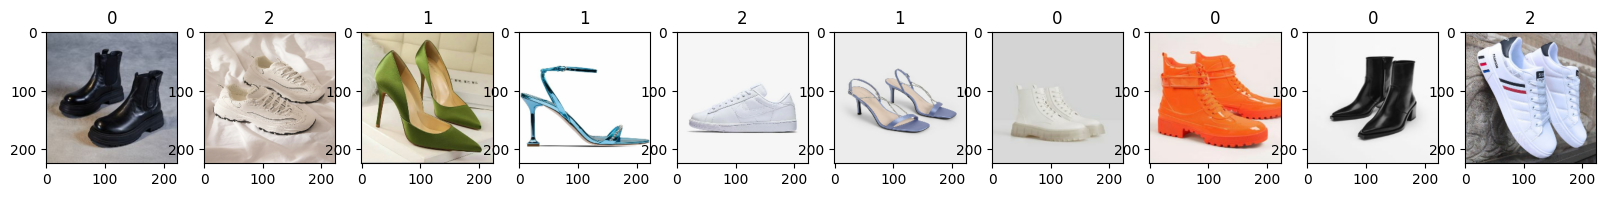

In [29]:
fig, ax = plt.subplots(ncols=10, figsize=(20,20))
for idx, img in enumerate(batch[0][:10]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [30]:
data = data.map(lambda x, y: (x/255.0, y))
print("Data type after normalization: {}".format(data.element_spec))
print("Data shape after normalization: {}".format(data.element_spec))
print("Jumlah data", len(data))

Data type after normalization: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
Data shape after normalization: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
Jumlah data 19


In [31]:
train_size = int(len(data)* 0.8)
val_size = int(len(data) * 0.1)
test_size = int(len(data)* 0.1)

print(train_size)
print(val_size)
print(test_size)

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

15
1
1


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
model_vgg = Sequential()

model_vgg.add(Conv2D(64, kernel_size=(3, 3), strides=(1, 1), activation='relu', input_shape=(224, 224, 3)))
model_vgg.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_vgg.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model_vgg.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model_vgg.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model_vgg.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model_vgg.add(Flatten())
model_vgg.add(Dense(256, activation='relu'))
model_vgg.add(Dense(256, activation='relu'))
model_vgg.add(Dense(5, activation='sigmoid'))

model_vgg.compile(optimizer='adamax', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_vgg.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 222, 222, 64)      1792      
                                                                 
 conv2d_5 (Conv2D)           (None, 220, 220, 64)      36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 110, 110, 64)      0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 108, 108, 128)     73856     
                                                                 
 conv2d_7 (Conv2D)           (None, 106, 106, 128)     147584    
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 53, 53, 128)       0         
 g2D)                                                 

In [33]:
history = model_vgg.fit(train,  epochs=100, validation_data=val)

Epoch 1/100
15/15 [==============================] - 7s 328ms/step - loss: 2.1938 - accuracy: 0.3958 - val_loss: 0.7953 - val_accuracy: 0.6250
Epoch 2/100
15/15 [==============================] - 4s 222ms/step - loss: 0.7406 - accuracy: 0.6833 - val_loss: 0.5670 - val_accuracy: 0.6875
Epoch 3/100
15/15 [==============================] - 4s 213ms/step - loss: 0.5833 - accuracy: 0.7292 - val_loss: 0.2848 - val_accuracy: 0.8125
Epoch 4/100
15/15 [==============================] - 4s 224ms/step - loss: 0.4829 - accuracy: 0.8125 - val_loss: 0.5336 - val_accuracy: 0.7500
Epoch 5/100
15/15 [==============================] - 6s 321ms/step - loss: 0.3606 - accuracy: 0.8625 - val_loss: 0.3475 - val_accuracy: 0.9375
Epoch 6/100
15/15 [==============================] - 4s 211ms/step - loss: 0.3289 - accuracy: 0.8750 - val_loss: 0.2405 - val_accuracy: 0.9375
Epoch 7/100
15/15 [==============================] - 4s 212ms/step - loss: 0.1889 - accuracy: 0.9333 - val_loss: 0.0384 - val_accuracy: 1.0000

In [34]:
history_dict = history.history

In [35]:
df = pd.DataFrame(history_dict)

In [36]:
df.to_excel('/content/drive/MyDrive/Googll Colab/datasetPandu/excel/History_VGGNet16_Kelas_SB 3.xlsx', index=False)

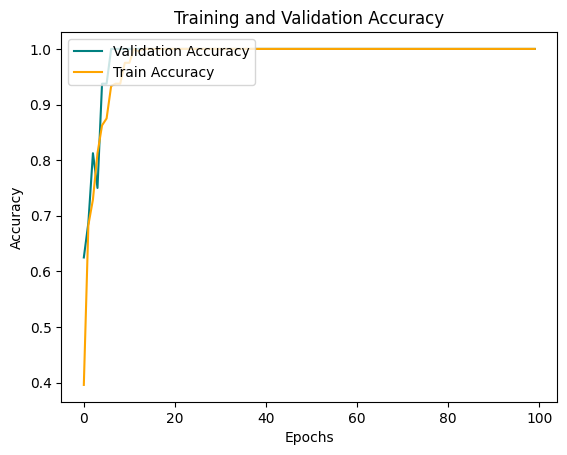

In [37]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'], color='teal', label='Validation Accuracy')
plt.plot(history.history['accuracy'], color='orange', label='Train Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc="upper left")
plt.show()

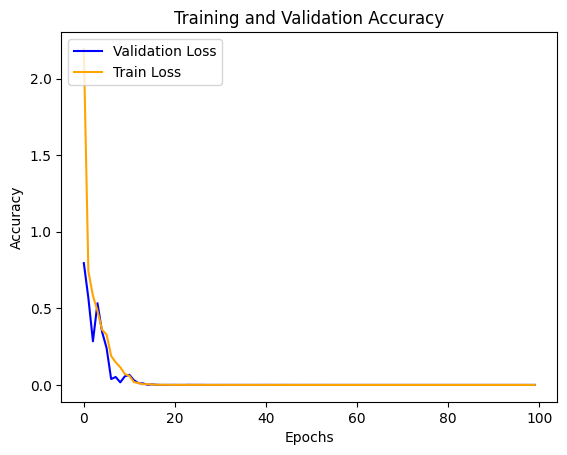

In [38]:
plt.plot(history.history['val_loss'], color='blue', label='Validation Loss')
plt.plot(history.history['loss'], color='orange', label='Train Loss')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc="upper left")
plt.show()

In [39]:
modelvggNet.evaluate(test)

1/1 [==============================] - 2s 2s/step - loss: 1.0505e-05 - accuracy: 1.0000


[1.0504870260774624e-05, 1.0]

In [41]:
modelvggNet.save('/content/drive/MyDrive/Googll Colab/datasetPandu/hasil/VGGNetUAS.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
